# Malaria Cell Classification - EDA and Model Training

This notebook loads the extracted image features, performs non-graphical and graphical EDA, trains the existing Random Forest model, adds a Logistic Regression baseline, compares both models, and saves both trained `.pkl` files.


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.2
FEATURE_COLUMNS = [
    "cell_area",
    "parasite_count",
    "parasite_area",
    "texture_contrast",
]
TARGET_COLUMN = "label"
LABEL_NAMES = {0: "Uninfected", 1: "Parasitized"}

DATA_PATH = Path("../extracted-csv/malaria_features.csv")
MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)


## Load and Clean Data


In [2]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Raw dataset shape: {df_raw.shape}")

# Hapus baris yang mungkin error (area sel = 0)
df = df_raw[df_raw["cell_area"] > 0].copy()
df["label_name"] = df[TARGET_COLUMN].map(LABEL_NAMES)

print(f"Cleaned dataset shape: {df.shape}")
print(f"Removed rows where cell_area <= 0: {len(df_raw) - len(df)}")
display(df.head())


Raw dataset shape: (27358, 5)
Cleaned dataset shape: (27358, 6)
Removed rows where cell_area <= 0: 0


,cell_area,parasite_count,parasite_area,texture_contrast,label,label_name
0,16954.0,1,208.5,366.991694,1,Parasitized
1,11529.5,1,144.0,445.258874,1,Parasitized
2,11486.0,1,215.0,389.118989,1,Parasitized
3,18251.0,2,172.5,389.324830,1,Parasitized
4,14787.0,1,110.0,440.254214,1,Parasitized


## Non-Graphical EDA


In [3]:
print("--- Data Types ---")
print(df[FEATURE_COLUMNS + [TARGET_COLUMN]].dtypes)

print("\n--- Missing Values ---")
print(df[FEATURE_COLUMNS + [TARGET_COLUMN]].isna().sum())

print("\n--- Duplicate Rows ---")
duplicate_rows = df.duplicated(subset=FEATURE_COLUMNS + [TARGET_COLUMN]).sum()
print(f"Duplicate feature/label rows: {duplicate_rows}")

print("\n--- Class Distribution ---")
class_distribution = df[TARGET_COLUMN].value_counts().sort_index().rename(index=LABEL_NAMES)
print(class_distribution)
print((class_distribution / len(df) * 100).round(2).astype(str) + "%")

print("\n--- Zero Value Counts ---")
zero_value_counts = (df[FEATURE_COLUMNS] == 0).sum()
print(zero_value_counts)
print((zero_value_counts / len(df) * 100).round(2).astype(str) + "%")


--- Data Types ---
cell_area           float64
parasite_count        int64
parasite_area       float64
texture_contrast    float64
label                 int64
dtype: object

--- Missing Values ---
cell_area           0
parasite_count      0
parasite_area       0
texture_contrast    0
label               0
dtype: int64

--- Duplicate Rows ---
Duplicate feature/label rows: 0

--- Class Distribution ---
label
Uninfected     13679
Parasitized    13679
Name: count, dtype: int64
label
Uninfected     50.0%
Parasitized    50.0%
Name: count, dtype: str

--- Zero Value Counts ---
cell_area               0
parasite_count      14208
parasite_area       14208
texture_contrast        0
dtype: int64
cell_area             0.0%
parasite_count      51.93%
parasite_area       51.93%
texture_contrast      0.0%
dtype: str


In [4]:
print("--- Feature Summary ---")
feature_summary = df[FEATURE_COLUMNS].describe().T
feature_summary["median"] = df[FEATURE_COLUMNS].median()
display(feature_summary.round(3))

print("--- Feature Summary by Class ---")
feature_summary_by_class = df.groupby("label_name")[FEATURE_COLUMNS].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
])
display(feature_summary_by_class.round(3))

print("--- Correlation Matrix ---")
correlation_matrix = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr(numeric_only=True)
display(correlation_matrix.round(3))


--- Feature Summary ---


,count,mean,std,min,25%,50%,75%,max,median
cell_area,27358.0,12462.201,2968.475,1105.000,10554.125,12350.750,14205.0,43531.000,12350.750
parasite_count,27358.0,0.621,0.750,0.000,0.000,0.000,1.0,6.000,0.000
parasite_area,27358.0,72.066,88.496,0.000,0.000,0.000,139.0,741.000,0.000
texture_contrast,27358.0,465.193,67.410,230.809,420.877,460.728,503.7,1041.316,460.728


--- Feature Summary by Class ---


cell_area                                                 \
                count       mean   median       std     min      max   
label_name                                                             
Parasitized     13679  12578.735  12394.0  3189.986  1105.0  43531.0   
Uninfected      13679  12345.667  12309.0  2724.180  1627.0  30857.0   

            parasite_count                       ... parasite_area          \
                     count   mean median    std  ...        median     std   
label_name                                       ...                         
Parasitized          13679  1.204    1.0  0.637  ...         138.0  72.958   
Uninfected           13679  0.038    0.0  0.202  ...           0.0  33.815   

                        texture_contrast                                     \
             min    max            count     mean   median     std      min   
label_name                                                                    
Parasitized  0.0  661.5            13679  462.511  458.798  66.689  230.809   
Uninfected   0.0  741.0            13679  467.875  463.062  68.019  233.554   

                       
                  max  
label_name             
Parasitized   981.645  
Uninfected   1041.316  

[2 rows x 24 columns]

--- Correlation Matrix ---


,cell_area,parasite_count,parasite_area,texture_contrast,label
cell_area,1.000,0.136,0.206,-0.416,0.039
parasite_count,0.136,1.000,0.826,-0.058,0.777
parasite_area,0.206,0.826,1.000,-0.082,0.766
texture_contrast,-0.416,-0.058,-0.082,1.000,-0.040
label,0.039,0.777,0.766,-0.040,1.000


## Graphical EDA


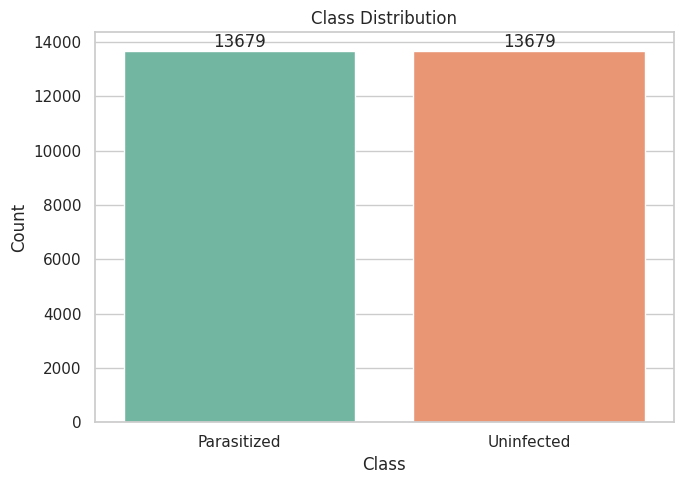

In [5]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="label_name", hue="label_name", palette="Set2", legend=False)
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.show()


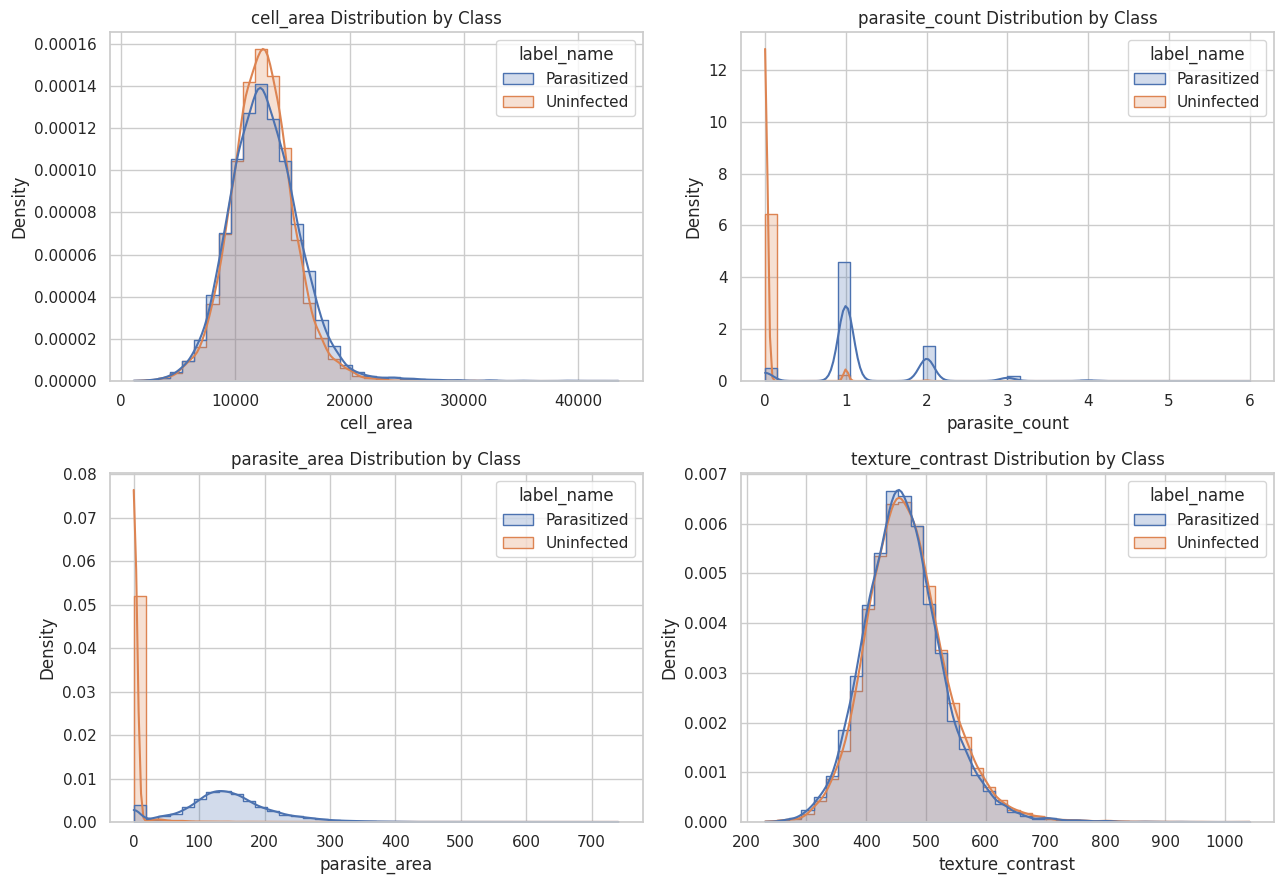

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feature in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.histplot(
        data=df,
        x=feature,
        hue="label_name",
        bins=40,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f"{feature} Distribution by Class")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


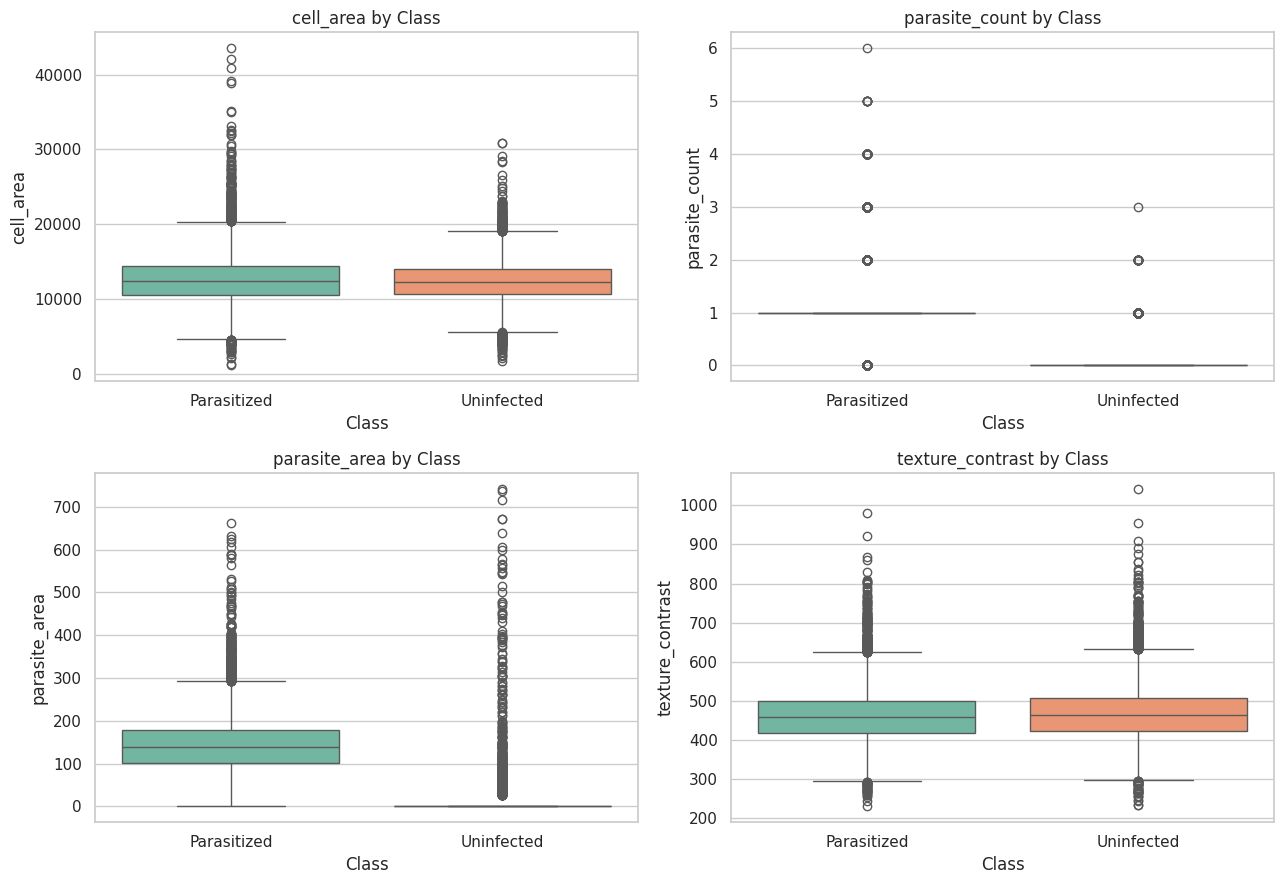

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feature in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.boxplot(
        data=df,
        x="label_name",
        y=feature,
        hue="label_name",
        palette="Set2",
        legend=False,
        ax=ax,
    )
    ax.set_title(f"{feature} by Class")
    ax.set_xlabel("Class")
    ax.set_ylabel(feature)
plt.tight_layout()
plt.show()


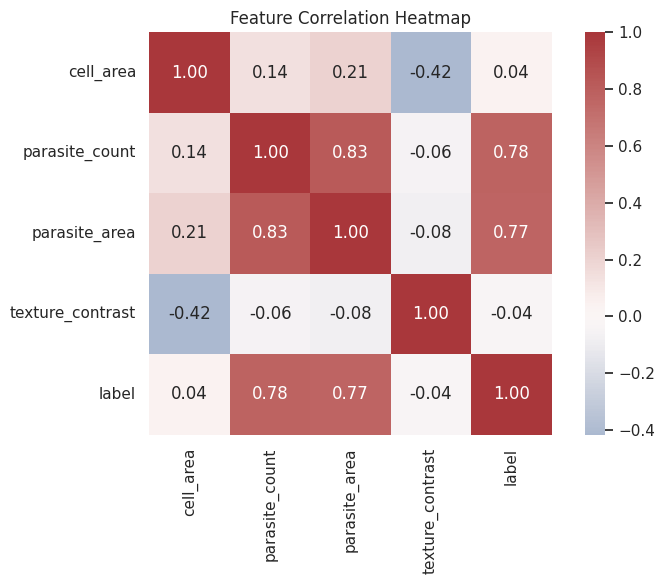

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## Train/Test Split


In [9]:
# PISAHIN FITUR (X) DAN LABEL (y)
# X adalah data yang dipakai untuk menebak (Luas sel, jumlah parasit, dll)
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

# DATA SPLITTING
# 80% training, 20% test. Stratify keeps both classes balanced in train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Jumlah data training : {len(X_train)}")
print(f"Jumlah data testing  : {len(X_test)}")
print("\nDistribusi label training:")
print(y_train.value_counts().sort_index().rename(index=LABEL_NAMES))
print("\nDistribusi label testing:")
print(y_test.value_counts().sort_index().rename(index=LABEL_NAMES))


Jumlah data training : 21886
Jumlah data testing  : 5472

Distribusi label training:
label
Uninfected     10943
Parasitized    10943
Name: count, dtype: int64

Distribusi label testing:
label
Uninfected     2736
Parasitized    2736
Name: count, dtype: int64


## Model 1 - Random Forest


Mulai melatih Random Forest...


Training Random Forest selesai!
--- RANDOM FOREST EVALUATION METRICS ---
                 precision    recall  f1-score   support

 Uninfected (0)       0.92      0.97      0.94      2736
Parasitized (1)       0.96      0.92      0.94      2736

       accuracy                           0.94      5472
      macro avg       0.94      0.94      0.94      5472
   weighted avg       0.94      0.94      0.94      5472



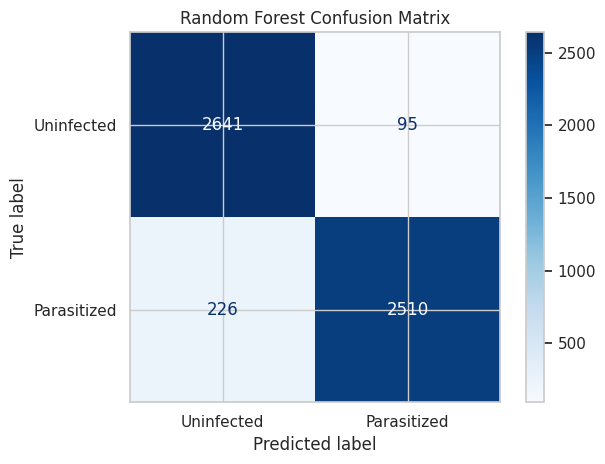

In [10]:
print("Mulai melatih Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
print("Training Random Forest selesai!")

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("--- RANDOM FOREST EVALUATION METRICS ---")
print(classification_report(y_test, y_pred_rf, target_names=["Uninfected (0)", "Parasitized (1)"]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
display_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Uninfected", "Parasitized"],
)
display_rf.plot(cmap="Blues", values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


--- RANDOM FOREST FEATURE IMPORTANCE ---


,feature,importance
2,parasite_area,0.428605
1,parasite_count,0.391749
0,cell_area,0.091484
3,texture_contrast,0.088162


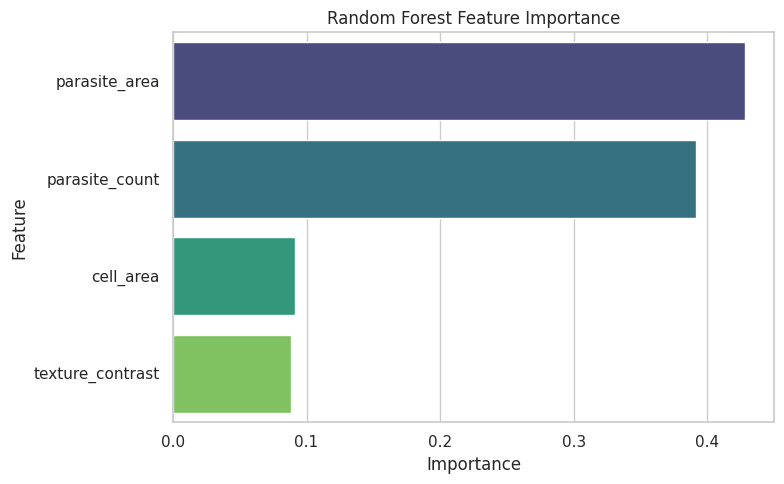

In [11]:
print("--- RANDOM FOREST FEATURE IMPORTANCE ---")
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": importances,
}).sort_values("importance", ascending=False)
display(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Model 2 - Logistic Regression


Mulai melatih Logistic Regression...
Training Logistic Regression selesai!
--- LOGISTIC REGRESSION EVALUATION METRICS ---
                 precision    recall  f1-score   support

 Uninfected (0)       0.93      0.97      0.95      2736
Parasitized (1)       0.97      0.92      0.94      2736

       accuracy                           0.95      5472
      macro avg       0.95      0.95      0.95      5472
   weighted avg       0.95      0.95      0.95      5472



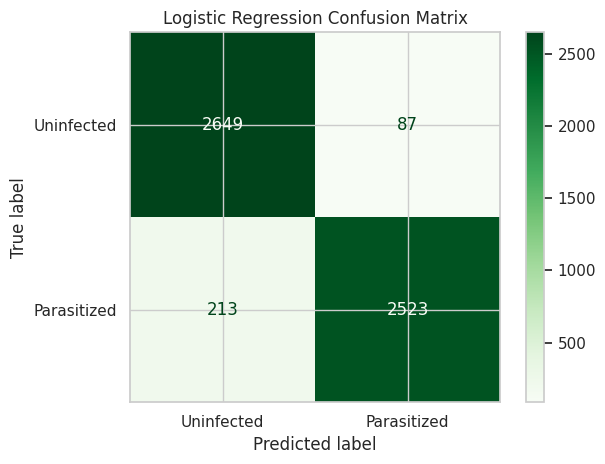

In [12]:
print("Mulai melatih Logistic Regression...")
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

logistic_model.fit(X_train, y_train)
print("Training Logistic Regression selesai!")

y_pred_lr = logistic_model.predict(X_test)
y_proba_lr = logistic_model.predict_proba(X_test)[:, 1]

print("--- LOGISTIC REGRESSION EVALUATION METRICS ---")
print(classification_report(y_test, y_pred_lr, target_names=["Uninfected (0)", "Parasitized (1)"]))

cm_lr = confusion_matrix(y_test, y_pred_lr)
display_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Uninfected", "Parasitized"],
)
display_lr.plot(cmap="Greens", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()


## Model Comparison


In [13]:
comparison_metrics = pd.DataFrame([
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "precision_parasitized": precision_score(y_test, y_pred_rf, zero_division=0),
        "recall_parasitized": recall_score(y_test, y_pred_rf, zero_division=0),
        "f1_parasitized": f1_score(y_test, y_pred_rf, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_rf),
    },
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, y_pred_lr),
        "precision_parasitized": precision_score(y_test, y_pred_lr, zero_division=0),
        "recall_parasitized": recall_score(y_test, y_pred_lr, zero_division=0),
        "f1_parasitized": f1_score(y_test, y_pred_lr, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_lr),
    },
]).sort_values("f1_parasitized", ascending=False)

display(comparison_metrics.round(4))

best_model = comparison_metrics.iloc[0]
print(
    f"Model terbaik berdasarkan F1 Parasitized: {best_model['model']} "
    f"(F1={best_model['f1_parasitized']:.4f})"
)


,model,accuracy,precision_parasitized,recall_parasitized,f1_parasitized,roc_auc
1,Logistic Regression,0.9452,0.9667,0.9221,0.9439,0.9666
0,Random Forest,0.9413,0.9635,0.9174,0.9399,0.9631


Model terbaik berdasarkan F1 Parasitized: Logistic Regression (F1=0.9439)


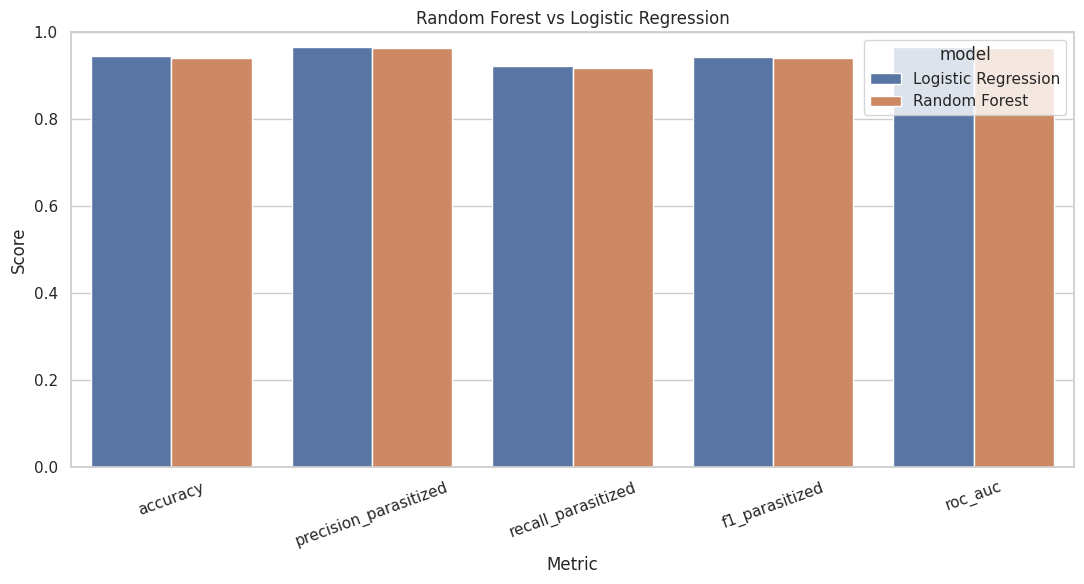

In [14]:
comparison_plot = comparison_metrics.melt(
    id_vars="model",
    value_vars=["accuracy", "precision_parasitized", "recall_parasitized", "f1_parasitized", "roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=comparison_plot, x="metric", y="score", hue="model")
plt.title("Random Forest vs Logistic Regression")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Learning Curves

Learning curves show whether each model improves as more training data is available. These plots use F1 score with cross-validation, so they are different from epoch-by-epoch neural-network training curves.


,model,training_examples,train_f1_mean,validation_f1_mean
0,Random Forest,2188,0.9999,0.9375
1,Random Forest,7112,0.9999,0.9400
2,Random Forest,12037,0.9999,0.9394
3,Random Forest,16961,0.9999,0.9388
4,Random Forest,21886,0.9999,0.9382
5,Logistic Regression,2188,0.9428,0.9431
6,Logistic Regression,7112,0.9449,0.9434
7,Logistic Regression,12037,0.9444,0.9433
8,Logistic Regression,16961,0.9441,0.9433
9,Logistic Regression,21886,0.9433,0.9433


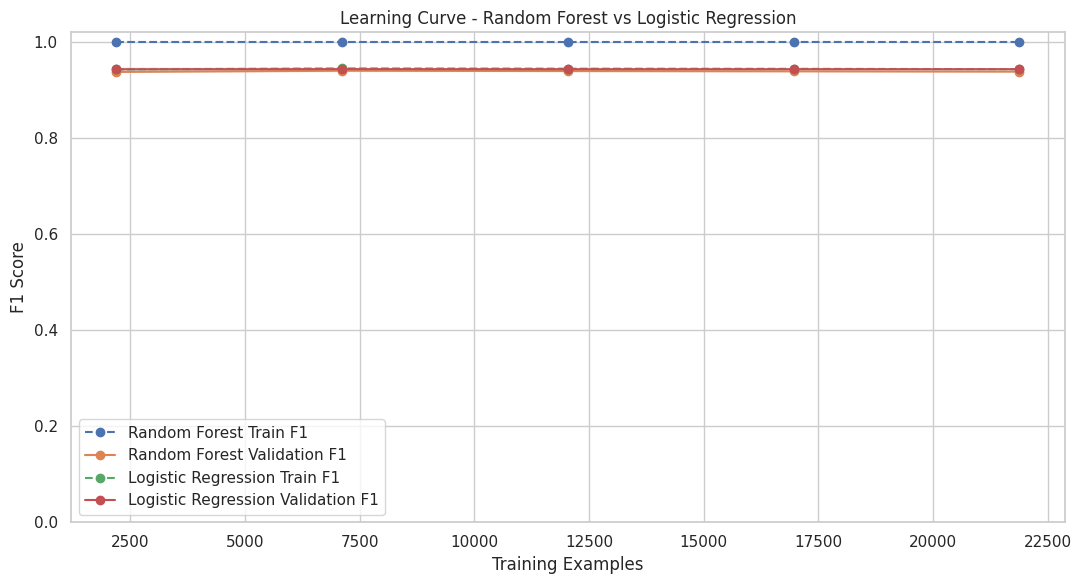

In [15]:
learning_curve_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    ),
}

train_sizes = np.linspace(0.1, 1.0, 5)
learning_curve_rows = []

plt.figure(figsize=(11, 6))

for model_name, estimator in learning_curve_models.items():
    train_sizes_abs, train_scores, validation_scores = learning_curve(
        estimator,
        X,
        y,
        train_sizes=train_sizes,
        cv=5,
        scoring="f1",
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    for size, train_score, val_score in zip(train_sizes_abs, train_mean, validation_mean):
        learning_curve_rows.append({
            "model": model_name,
            "training_examples": size,
            "train_f1_mean": train_score,
            "validation_f1_mean": val_score,
        })

    plt.plot(train_sizes_abs, train_mean, marker="o", linestyle="--", label=f"{model_name} Train F1")
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.12)

    plt.plot(train_sizes_abs, validation_mean, marker="o", label=f"{model_name} Validation F1")
    plt.fill_between(train_sizes_abs, validation_mean - validation_std, validation_mean + validation_std, alpha=0.12)

learning_curve_df = pd.DataFrame(learning_curve_rows)
display(learning_curve_df.round(4))

plt.title("Learning Curve - Random Forest vs Logistic Regression")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()


## Save Models


In [16]:
rf_model_path = MODEL_DIR / "malaria_rf_model.pkl"
logistic_model_path = MODEL_DIR / "malaria_logistic_regression_model.pkl"

joblib.dump(rf_model, rf_model_path)
joblib.dump(logistic_model, logistic_model_path)

print(f"Random Forest model berhasil disimpan sebagai: {rf_model_path}")
print(f"Logistic Regression model berhasil disimpan sebagai: {logistic_model_path}")


Random Forest model berhasil disimpan sebagai: ../model/malaria_rf_model.pkl
Logistic Regression model berhasil disimpan sebagai: ../model/malaria_logistic_regression_model.pkl
